In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("pizza_sales.csv")
rd = pd.read_csv("pizza_sales.csv")
df.tail()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,48616,21348,ckn_alfredo_m,1,31/12/2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31/12/2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31/12/2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31/12/2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,48620,21350,bbq_ckn_s,1,31/12/2015,23:02:05,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [3]:
df.isnull().sum()
rd["order_date"]

0          1/1/2015
1          1/1/2015
2          1/1/2015
3          1/1/2015
4          1/1/2015
            ...    
48615    31/12/2015
48616    31/12/2015
48617    31/12/2015
48618    31/12/2015
48619    31/12/2015
Name: order_date, Length: 48620, dtype: str

In [ ]:
###KPIS
total_revenue = df["total_price"].sum()
total_pizza_sold = df["quantity"].sum()
total_orders = df["order_id"].count()
average_order_value = total_revenue / total_orders
average_pizza_per_order = total_pizza_sold / total_orders

In [ ]:
print(f"Total Revenue:Rs {total_revenue:,.2f}")
print(f"Total Pizza Sold: {total_pizza_sold}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value(AOV):{average_order_value:.2f}")
print(f"Average Pizza Per Order: {average_pizza_per_order:.2f}")

Total Revenue:Rs 817,860.05
Total Pizza Sold: 49574
Total Orders: 48620
Average Order Value(AOV):16.82
Average Pizza Per Order: 1.02


In [ ]:
most_used_ingredients = df["pizza_ingredients"].mode()
most_used_ingredients

0    Pepperoni, Mushrooms, Red Onions, Red Peppers,...
Name: pizza_ingredients, dtype: str

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  str    
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  str    
 5   order_time         48620 non-null  str    
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  str    
 9   pizza_category     48620 non-null  str    
 10  pizza_ingredients  48620 non-null  str    
 11  pizza_name         48620 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 4.5 MB


In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"], format="mixed")
df["OrderMonth"] = df["order_date"].dt.month
df["OrderDay"] = df["order_date"].dt.day
df["OrderMonthName"] = df["order_date"].dt.month_name()
df["OrderDayName"] = df["order_date"].dt.day_name()

In [ ]:
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
df["OrderDayName"] = pd.Categorical(df["OrderDayName"], categories=days)
df["OrderDayName"].unique()

['Thursday', 'Sunday', 'Wednesday', 'Friday', 'Monday', 'Saturday', 'Tuesday']
Categories (7, str): ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

In [ ]:
total_orders_by_day = (
    df.groupby("OrderDayName", observed=False)["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "Total_Order"})
)
total_orders_by_day

,OrderDayName,Total_Order
0,Sunday,6063
1,Monday,6577
2,Tuesday,6833
3,Wednesday,6907
4,Thursday,7243
5,Friday,7723
6,Saturday,7274


In [ ]:
total_orders_by_month = (
    df.groupby(["OrderMonth", "OrderMonthName"])["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "Total Order"})[["OrderMonthName", "Total Order"]]
)

total_orders_by_month

,OrderMonthName,Total Order
0,January,4288
1,February,3821
2,March,4251
3,April,4182
4,May,4008
5,June,4044
6,July,4212
7,August,4141
8,September,3780
9,October,4045


<BarContainer object of 7 artists>

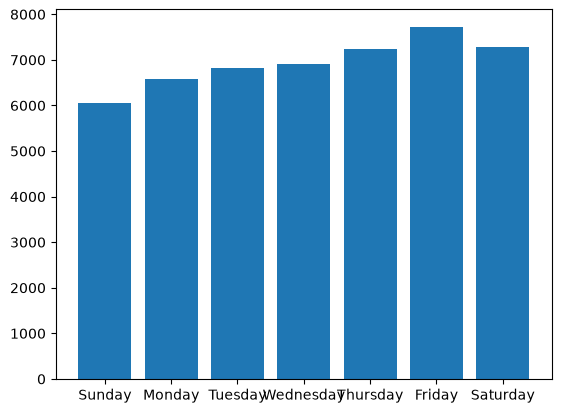

In [ ]:
plt.bar(total_orders_by_day["OrderDayName"], total_orders_by_day["Total_Order"])

Text(0.5, 1.0, 'Total Order Per Day')

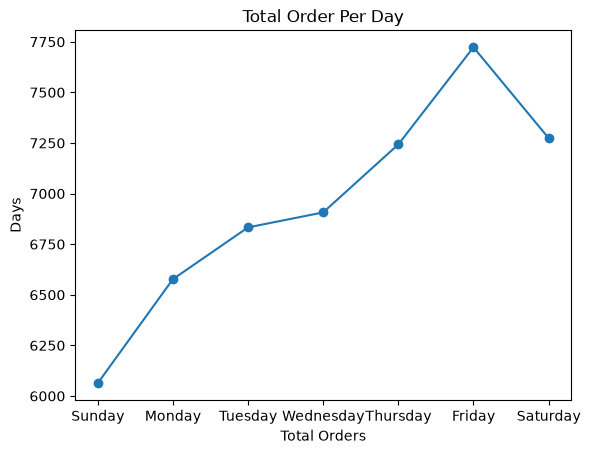

In [42]:
plt.plot(total_orders_by_day["OrderDayName"], total_orders_by_day["Total_Order"],marker='o')
plt.xlabel('Total Orders')
plt.ylabel('Days')
plt.title('Total Order Per Day')